In [16]:
# Importar librerias

import torch
import numpy as np

from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler

In [17]:
# Numero de sub procesos
num_workers = 0

# El tamaño del batch
batch_size = 20

# Convertir nuestros datos a tensores
transform = transforms.ToTensor()

# Seleccionar los dataset:  train y test
train_data = datasets.MNIST(root='data', train=True,
                                   download=True, transform=transform)

test_data = datasets.MNIST(root='data', train=False,
                                  download=True, transform=transform)

# loader
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    num_workers=num_workers)

test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_workers)

In [18]:
# Numero de imagenes en el dataset train y test
len(train_data), len(test_data)

(60000, 10000)

In [19]:
# Visualizacion de datos
import matplotlib.pyplot as plt
%matplotlib inline

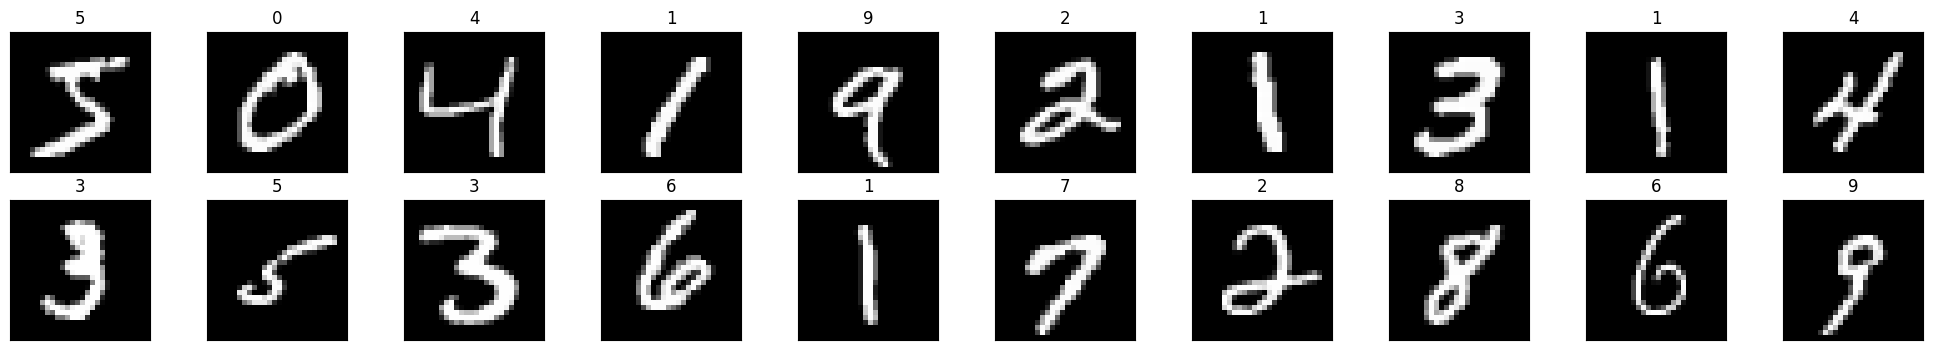

In [20]:
# Llamar un batch del dataset train
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

# Plotear el batch
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[]) # Division con 20//2  para obtener un entero
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    # print out the correct label for each image
    # .item() gets the value contained in a Tensor
    ax.set_title(str(labels[idx].item()))

In [21]:
# Definir la arquitectura - > Functional

import torch.nn as nn
import torch.nn.functional as F

# Definir la nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # Derfinir el numero de nodos en las capa oculta: 2
        hidden_1 = 512
        hidden_2 = 512

        # capa linear entrada 784
        self.fc1 = nn.Linear(28 * 28, hidden_1 )
        # segunda capa
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        # Capa de salida
        self.fc3 = nn.Linear(hidden_2, 10)
        # Droput, previene sobre entranmiento
        self.dropout = nn.Dropout(0.2)  #
    
    def forward(self, x):
        # Flatten
        x = x.view(-1, 28 * 28)
        # Añadimos la primera capa
        x = F.relu(self.fc1(x))
        # Aplica dropout
        x = self.dropout(x)
        # Añado la 2da capa
        x = F.relu(self.fc2(x))
        # Añadimos droput a la 2da capa
        x = self.dropout(x)
        # Añado la capa de salida
        x = self.fc3(x)
        return x

# Inicializamos el modelo

model = Net()
print (model)

Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [22]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [23]:
# Entrenar el mdoelo

# Numero de epocas
n_epochs = 5

model.train()

for epoch in range(n_epochs):
    train_loss = 0.0

    # Entrenamiento
    for data, target in train_loader:
      optimizer.zero_grad() # Limpiar gradientes
      output = model(data) # Obtengo el y sombrero,luego de hacer fordward
      loss = criterion(output, target)
      loss.backward() # Calcular la gradiente
      optimizer.step()  # Actualziar los pesos
      train_loss += loss.item()*data.size(0)  # los datos de loss
    
    # Imprimo resultados
    train_loss = train_loss/len(train_loader.dataset)

    print('Epoch: {} \tTraining Loss: {:.6f}'.format(
        epoch+1, 
        train_loss
        ))

Epoch: 1 	Training Loss: 0.819931
Epoch: 2 	Training Loss: 0.323159
Epoch: 3 	Training Loss: 0.252202
Epoch: 4 	Training Loss: 0.203805
Epoch: 5 	Training Loss: 0.172207


In [24]:
# Revisar la red entrenada con test

# Incializar
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval() # preparo para evaluacion

for data, target in test_loader:
  output = model(data)
  loss = criterion(output, target)
  test_loss += loss.item()*data.size(0)
  # Comparar las predicciones
  _, pred = torch.max(output, 1)
  correct = np.squeeze(pred.eq(target.data.view_as(pred)))
  # Calcula la exactitud
  for i in range(batch_size):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# Imprimo resutlados
test_loss = test_loss/len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            str(i), 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.142994

Test Accuracy of     0: 98% (966/980)
Test Accuracy of     1: 98% (1119/1135)
Test Accuracy of     2: 93% (967/1032)
Test Accuracy of     3: 95% (967/1010)
Test Accuracy of     4: 96% (944/982)
Test Accuracy of     5: 95% (855/892)
Test Accuracy of     6: 96% (921/958)
Test Accuracy of     7: 93% (965/1028)
Test Accuracy of     8: 93% (913/974)
Test Accuracy of     9: 94% (953/1009)

Test Accuracy (Overall): 95% (9570/10000)


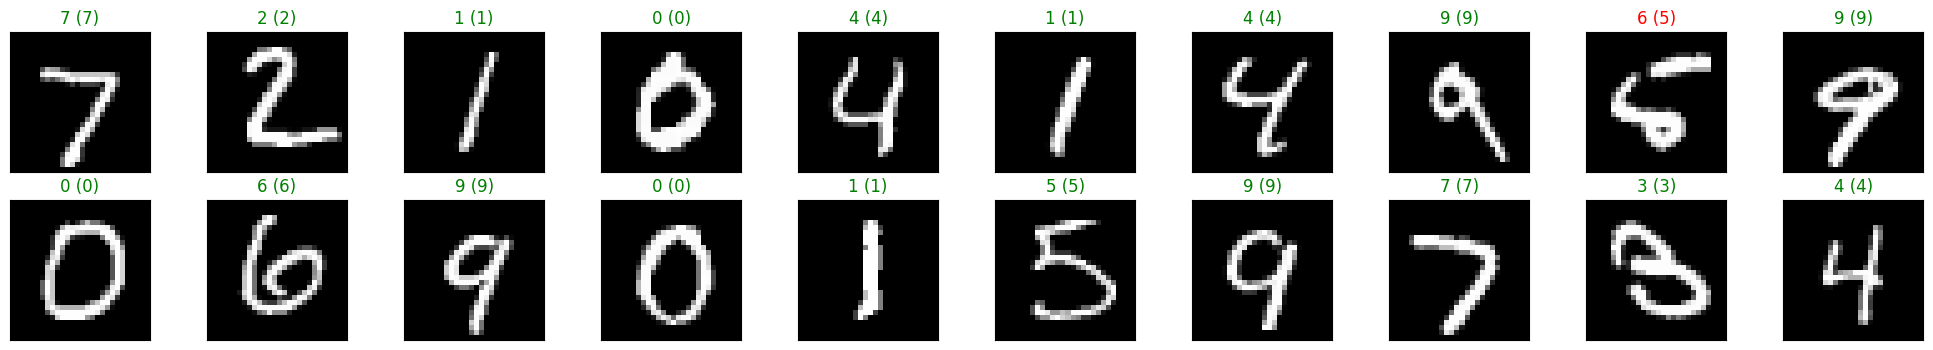

In [25]:
# Plotear los resutlados
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Obtengo una muestra
output = model(images)
_, preds = torch.max(output, 1) # Convierto a probabilidades
images = images.numpy()

# Plot
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])  # Division con 20//2  para obtener un entero
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(str(preds[idx].item()), str(labels[idx].item())),
                 color=("green" if preds[idx]==labels[idx] else "red"))

## Trabajo

- A la arquitectura añadir softmax
- Minimo 30 épocas de entrenamiento